XG BOOST MODEL FOR QUANT FEATURES

In [20]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np

# Load Dataset
df = pd.read_csv("filteredfinal.csv")

# Fix data types early
cols_to_numeric = ['QS Overall Score', '2024 Rank', '2025 Rank']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col].replace("-", np.nan), errors='coerce')

# Fill NaNs
df[cols_to_numeric] = df[cols_to_numeric].fillna(df[cols_to_numeric].mean())

# Define features (make sure these are all numeric in the dataset!)
features = ['Acceptance Rate', 'In-State Tuition', 'Out-of-State Tuition', 
            'Cost of Attendance', 'Graduation Rate', 'Median Salary', 'Average GPA',
            'Average GRE Score', '2025 Rank', '2024 Rank', 'Academic Reputation',
            'Employer Reputation', 'Faculty Student', 'Citations per Faculty',
            'International Faculty', 'International Students', 'International Research Network',
            'Employment Outcomes', 'Sustainability']

# Prepare data
X = df[features]
y = df['QS Overall Score']

# Double-check: ALL dtypes must be float or int!
print("X dtypes:\n", X.dtypes)
print("y dtype:\n", y.dtype)

# Split and model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)

xgb_model.fit(X_train, y_train)


X dtypes:
 Acceptance Rate                   float64
In-State Tuition                  float64
Out-of-State Tuition              float64
Cost of Attendance                float64
Graduation Rate                   float64
Median Salary                     float64
Average GPA                       float64
Average GRE Score                 float64
2025 Rank                         float64
2024 Rank                         float64
Academic Reputation               float64
Employer Reputation               float64
Faculty Student                   float64
Citations per Faculty             float64
International Faculty             float64
International Students            float64
International Research Network    float64
Employment Outcomes               float64
Sustainability                    float64
dtype: object
y dtype:
 float64


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [21]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = xgb_model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


RMSE: 0.23
R² Score: 0.99


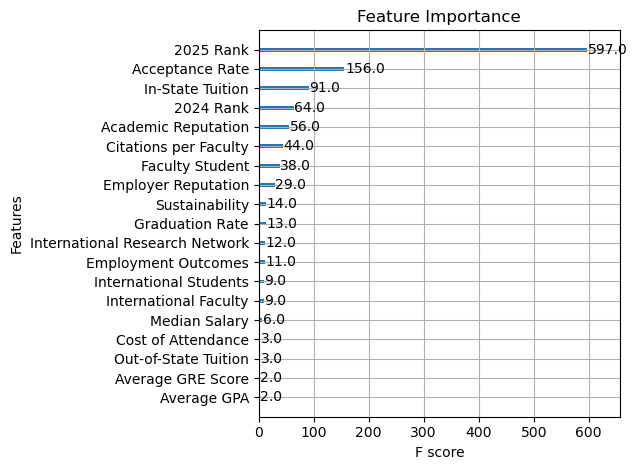

In [22]:
import matplotlib.pyplot as plt
xgb.plot_importance(xgb_model)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


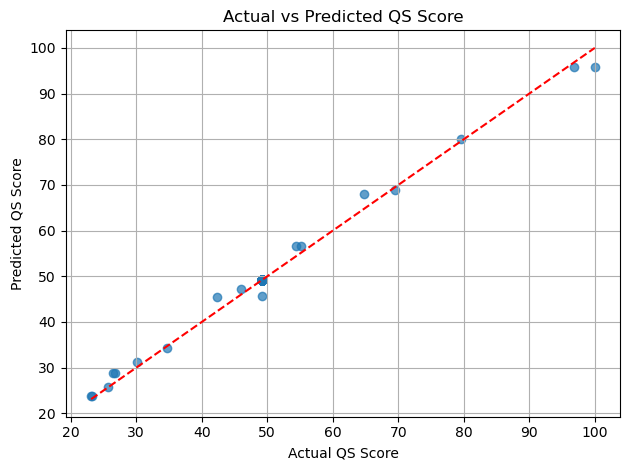

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual QS Score")
plt.ylabel("Predicted QS Score")
plt.title("Actual vs Predicted QS Score")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
from sklearn.metrics import mean_squared_error, r2_score

# On training data
y_train_pred = xgb_model.predict(X_train)
print("Train RMSE:", mean_squared_error(y_train, y_train_pred, squared=False))
print("Train R²:", r2_score(y_train, y_train_pred))

# You already have test scores


Train RMSE: 0.003439536385305845
Train R²: 0.9999978837045364


In [27]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Average:", scores.mean())


Cross-validated R² scores: [ 9.93276087e-01  9.77835917e-01  9.92824234e-01 -1.09769985e+18
  9.99953381e-01]
Average: -2.19539969225987e+17


In [30]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []

for fold, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    print(f"Fold {fold+1} R²: {r2}")
    r2_scores.append(r2)
print("y_test variance:", np.var(y_test))
print("\nAverage R²:", np.mean(r2_scores))


Fold 1 R²: 0.9928072567638195
Fold 2 R²: 0.9874981552352983
Fold 3 R²: 0.9704752091734051
Fold 4 R²: 0.9865658830834222
Fold 5 R²: 0.9839238174450283
y_test variance: 5.2223519239737834

Average R²: 0.9842540643401947


MODEL SAVING

In [37]:
import joblib

# Save the model
joblib.dump(xgb_model, 'xgb_qs_model.pkl')
print("Model exported as 'xgb_qs_model.pkl'")


Model exported as 'xgb_qs_model.pkl'


TESTING THE MODEL

In [ ]:
import pandas as pd
import joblib
from sklearn.metrics.pairwise import cosine_similarity

# Load the trained model and dataset
model = joblib.load("xgb_qs_model.pkl")
df = pd.read_csv("filteredfinal.csv")

# Convert necessary columns to numeric
df['QS Overall Score'] = pd.to_numeric(df['QS Overall Score'], errors='coerce')
df.dropna(subset=['QS Overall Score'], inplace=True)

Predicted QS Score: 52.115253

Top Recommended Universities:
                             University Name  QS Overall Score
1544               Michigan State University              51.9
3200                         Rice University              53.6
208           University Of California Davis              54.4
453        University Of Southern California              55.2
214   University Of California Santa Barbara              48.9


In [42]:
# Step 1: Define the user input
user_input = pd.DataFrame({
    'Acceptance Rate': [10],
    'In-State Tuition': [15000],
    'Out-of-State Tuition': [30000],
    'Cost of Attendance': [40000],
    'Graduation Rate': [85],
    'Median Salary': [70000],
    'Average GPA': [3.9],
    'Average GRE Score': [330],
    '2025 Rank': [10],
    '2024 Rank': [10],
    'Academic Reputation': [10],
    'Employer Reputation': [5],
    'Faculty Student': [60],
    'Citations per Faculty': [65],
    'International Faculty': [50],
    'International Students': [55],
    'International Research Network': [60],
    'Employment Outcomes': [68],
    'Sustainability': [70],
    'QS Overall Score': [0]  # Dummy, will be predicted
})

# Step 2: Predict the QS score
user_input_features = user_input.drop(columns=['QS Overall Score'])
predicted_score = xgb_model.predict(user_input_features)[0]
print("Predicted QS Score:", predicted_score)

# Step 3: Find top 5 closest universities by QS score
df['QS Score Diff'] = abs(df['QS Overall Score'] - predicted_score)
top_matches = df.nsmallest(5, 'QS Score Diff')

# Step 4: Output recommended universities
print("\nTop Recommended Universities:")
print(top_matches[['University Name', 'QS Overall Score']])

Predicted QS Score: 96.554375

Top Recommended Universities:
                            University Name  QS Overall Score
1420                     Harvard University              96.8
3630                    Stanford University              96.1
1436  Massachusetts Institute Of Technology             100.0
190      California Institute Of Technology              90.9
2824             University Of Pennsylvania              90.3


XG BOOST MODEL 1 ON GPA, GRE, Budget

In [10]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np

In [9]:
import matplotlib.pyplot as plt
import joblib

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [4]:
# Load Dataset
df = pd.read_csv("filteredfinal.csv")

# Convert relevant columns to numeric
df['QS Overall Score'] = pd.to_numeric(df['QS Overall Score'], errors='coerce')
df.dropna(subset=['QS Overall Score'], inplace=True)

# Only train on features that the user will actually input:
features = ['Out-of-State Tuition', 'Average GPA', 'Average GRE Score']

# Drop rows with missing values in selected features
df = df.dropna(subset=features)

# Prepare data for training
X = df[features]
y = df['QS Overall Score']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Train the model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [11]:
# Evaluate
y_pred = xgb_model.predict(X_test)
print(f"RMSE: {mean_squared_error(y_test, y_pred, squared=False):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

# Cross-validation
scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Average R²:", scores.mean())

# Save the model
joblib.dump(xgb_model, 'xgb_qs_model_1.pkl')
print("Model saved as 'xgb_qs_model_1.pkl'")

RMSE: 26.44
R² Score: 0.25
Cross-validated R² scores: [ 0.46806995 -0.10454673  0.05492757  0.4915819   0.52876411]
Average R²: 0.28775935951886805
Model saved as 'xgb_qs_model_1.pkl'


In [14]:
import joblib
from sklearn.metrics.pairwise import cosine_similarity

# Load model and dataset
model = joblib.load("xgb_qs_model_1.pkl")
df = pd.read_csv("filteredfinal.csv")
df['QS Overall Score'] = pd.to_numeric(df['QS Overall Score'], errors='coerce')
df.dropna(subset=['QS Overall Score'], inplace=True)

# User input only includes training features
user_input = pd.DataFrame({
    'Out-of-State Tuition': [100000],
    'Average GPA': [3.91],
    'Average GRE Score': [330]
})

# Predict
predicted_score = model.predict(user_input)[0]
print("Predicted QS Score:", predicted_score)

# Match universities
df['QS Score Diff'] = abs(df['QS Overall Score'] - predicted_score)
top_matches = df.nsmallest(5, 'QS Score Diff')

# Output
print("\nTop Recommended Universities:")
print(top_matches[['University Name', 'QS Overall Score']])


Predicted QS Score: 52.48926

Top Recommended Universities:
                             University Name  QS Overall Score
1544               Michigan State University              51.9
3200                         Rice University              53.6
208           University Of California Davis              54.4
453        University Of Southern California              55.2
214   University Of California Santa Barbara              48.9
